# Агент технічної підтримки на LangGraph

**Домашнє завдання 9, Тема 11.** Воленбовський Г. В.

Агент класифікує звернення користувача, шукає відповідь у базі FAQ, формує
стислу відповідь українською та визначає потребу ескалації до спеціаліста.

Робота побудована як порівняння: одну й ту саму задачу розв'язано двома
архітектурами графа на чотирьох різних моделях, а підсумковий варіант обрано
за результатами вимірювань.

## Зміст

1. Встановлення та перевірка версій
2. Ключ доступу до OpenRouter
3. База знань FAQ і типи даних
4. Фабрика моделей
5. Вузли графа
6. Дві архітектури графа: гібридна та повністю на LLM
7. Метрики якості
8. Експеримент 1: гібридна архітектура на чотирьох моделях
9. Експеримент 2: повністю LLM на двох найкращих моделях
10. Порівняльна таблиця та висновки
11. **Фінальне рішення:** `build_support_agent()` і `test_agent()`

> Обов'язковий за умовою запуск агента на п'яти тестових запитах міститься
> у розділі 11, у самому кінці ноутбука.

In [1]:
# Встановлення бібліотек. LangGraph фіксуємо на версії 1.x згідно з умовою завдання.
%pip install -q -U "langgraph>=1.0,<2.0" langchain-openai

from importlib.metadata import version, PackageNotFoundError

print("Версії встановлених пакетів:")
for pkg in ("langgraph", "langchain-core", "langchain-openai", "openai"):
    try:
        print(f"  {pkg}: {version(pkg)}")
    except PackageNotFoundError:
        print(f"  {pkg}: не встановлено")

major = int(version("langgraph").split(".")[0])
print()
print("LangGraph v1 підтверджено" if major == 1 else f"Увага: очікувалась версія 1.x, маємо {version('langgraph')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 21.5 MB/s eta 0:00:00
Версії встановлених пакетів:
  langgraph: 1.2.11
  langchain-core: 1.6.3
  langchain-openai: 1.6.2
  openai: 2.54.0

LangGraph v1 підтверджено


## 2. Ключ доступу до OpenRouter

Ключ вводиться вручну через `getpass` і потрапляє лише у змінну оточення,
а не в текст ноутбука. Завдяки цьому файл можна здавати без додаткового
очищення: ключа в ньому фізично немає.

Усі моделі викликаються через OpenRouter за OpenAI-сумісним протоколом,
тому використовується звичний клас `ChatOpenAI` зі зміненим `base_url`.

In [14]:
import os
from getpass import getpass

OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

_existing = os.environ.get("OPENROUTER_API_KEY")
_hint = " (Enter щоб залишити поточний)" if _existing else ""
_entered = getpass(f"Введіть ключ OpenRouter (sk-or-...){_hint}: ").strip()

if _entered:
    os.environ["OPENROUTER_API_KEY"] = _entered
    print(f"Новий ключ встановлено, довжина {len(_entered)} символів.")
elif _existing:
    print(f"Залишено попередній ключ, довжина {len(_existing)} символів.")
else:
    raise ValueError("Ключ не введено. Запустіть комірку ще раз і вставте ключ.")

Введіть ключ OpenRouter (sk-or-...) (Enter щоб залишити поточний): ··········
Новий ключ встановлено, довжина 73 символів.


In [16]:
from langchain_openai import ChatOpenAI

def try_config(name, **kwargs):
    """Перевіряє одну комбінацію параметрів і повертає True, якщо виклик пройшов."""
    try:
        client = ChatOpenAI(
            model="openai/gpt-5.6-luna",
            api_key=os.environ["OPENROUTER_API_KEY"],
            base_url=OPENROUTER_BASE_URL,
            timeout=60,
            max_retries=0,
            **kwargs,
        )
        result = client.invoke("Відповідай одним словом: столиця України?")
        print(f"[ПРАЦЮЄ]  {name}")
        print(f"          відповідь: {result.content!r}")
        print(f"          токени: {result.response_metadata.get('token_usage')}")
        return True
    except Exception as error:
        print(f"[ПОМИЛКА] {name}")
        print(f"          {type(error).__name__}: {str(error)[:200]}")
        return False

print("Перевірка комбінацій параметрів для openai/gpt-5.6-luna\n")

try_config("A. temperature=0 + require_parameters",
           temperature=0,
           extra_body={"provider": {"require_parameters": True}})
print()
try_config("B. temperature=0, без require_parameters",
           temperature=0)
print()
try_config("C. без temperature, з require_parameters",
           extra_body={"provider": {"require_parameters": True}})
print()
try_config("D. без temperature, без require_parameters")

Перевірка комбінацій параметрів для openai/gpt-5.6-luna

[ПОМИЛКА] A. temperature=0 + require_parameters
          OpenAIModelNotFoundError: Error code: 404 - {'error': {'message': 'No endpoints found that can handle the requested parameters. To learn more about provider routing, visit: https://openrouter.ai/docs/guides/routing/provider-se

[ПРАЦЮЄ]  B. temperature=0, без require_parameters
          відповідь: 'Київ'
          токени: {'completion_tokens': 7, 'prompt_tokens': 20, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': True, 'cost_details': {'upstream_inference_cost': 1.24e-05, 'upstream_inference_prompt_cost': 4e-06, 'upstream_inference_completions_cost': 8.4e-06}}

[ПРАЦЮЄ]  C. без temperature, з require_paramet

True

## 3. База знань FAQ і типи даних

База знань задана умовою завдання і наводиться без змін. Структури
`QueryClassification` та `SupportAgentState` також узяті з шаблона.

Додатково фіксуємо еталон: очікувані категорії та очікувані рішення щодо
ескалації для п'яти тестових запитів. Вони потрібні далі для вимірювання
точності, бо самих лише метрик з умови для порівняння архітектур замало:
показник Escalation Rate у 40 відсотків можна отримати і на помилковій парі
запитів.

In [17]:
from typing import TypedDict, Literal, Optional, List

FAQ_DATABASE = {
    "password": [
        "Скидання пароля: Натисніть 'Забули пароль?' → введіть email → перевірте пошту",
        "Новий пароль: мінімум 8 символів з літерами та цифрами",
        "Лист не прийшов - перевірте папку спам"
    ],
    "payment": [
        "Перевірте дані картки та баланс",
        "Подвійне списання повернеться автоматично за 3-5 днів",
        "Зміна тарифу: Профіль → Підписка"
    ],
    "technical": [
        "Оновіть сторінку (F5) або очистьте кеш",
        "Спробуйте інший браузер",
        "Перевірте status.ourservice.com"
    ],
    "account": [
        "Перевірте правильність email",
        "Корпоративні акаунти: розділ 'Управління командою'",
        "Блокування - зверніться до підтримки"
    ],
    "general": [
        "Підтримка працює 24/7",
        "Час відповіді: 2-4 години"
    ]
}


class QueryClassification(TypedDict):
    """Структура класифікації як у конспекті"""
    type: Literal["problem", "question", "complaint"]
    category: Literal["password", "payment", "technical", "account", "general"]
    urgency: Literal["low", "medium", "high"]
    summary: str


class SupportAgentState(TypedDict):
    """Стан агента"""
    user_query: str
    classification: Optional[QueryClassification]
    search_results: Optional[List[str]]
    draft_response: Optional[str]
    needs_escalation: bool


TEST_QUERIES = [
    "Я забув пароль від свого акаунту, як його відновити?",
    "З мене двічі зняли гроші за підписку! Це шахрайство! Поверніть кошти негайно!",
    "Чи можу я змінити тарифний план на дешевший?",
    "Сайт не працює вже третю годину! Коли полагодите?",
    "Як додати нового користувача до корпоративного акаунту?"
]

# Еталон для вимірювання точності.
# Категорія та ескалація задані таблицею з умови, тип узятий з наведеного
# прикладу очікуваного виводу.
EXPECTED = [
    {"category": "password",  "escalation": False, "type": "problem"},
    {"category": "payment",   "escalation": True,  "type": "complaint"},
    {"category": "payment",   "escalation": False, "type": "question"},
    {"category": "technical", "escalation": True,  "type": "complaint"},
    {"category": "account",   "escalation": False, "type": "question"},
]

print(f"Категорій у базі FAQ: {len(FAQ_DATABASE)}")
print(f"Усього пунктів FAQ: {sum(len(v) for v in FAQ_DATABASE.values())}")
print(f"Тестових запитів: {len(TEST_QUERIES)}, еталонних записів: {len(EXPECTED)}")
print(f"Очікувана частка ескалацій: {sum(e['escalation'] for e in EXPECTED)}/{len(EXPECTED)}")

Категорій у базі FAQ: 5
Усього пунктів FAQ: 14
Тестових запитів: 5, еталонних записів: 5
Очікувана частка ескалацій: 2/5


## 4. Фабрика моделей
Усі моделі створюються однаково, різниця лише в ідентифікаторі моделі.
Параметр `require_parameters` свідомо не використовується: він несумісний з
`temperature` у частини моделей, бо їхні провайдери не декларують підтримку
цього параметра, і маршрутизація OpenRouter відсікає всі доступні ендпоінти.
Відтворюваність експерименту важливіша, тому залишено `temperature=0`.

In [44]:
from langchain_openai import ChatOpenAI

# Учасники порівняння: дві платні та дві безкоштовні моделі.
MODELS = {
    "luna":      "openai/gpt-5.6-luna",
    "gpt5_mini": "openai/gpt-5-mini",
    "nemotron":  "nvidia/nemotron-3-super-120b-a12b:free",
    "dots":      "dots-studio/dots-3-note-preview:free",
}

# Суддя оцінює релевантність відповідей і не є учасником порівняння.
JUDGE_MODEL = "anthropic/claude-haiku-4.5"


def make_llm(model: str, temperature=0.0) -> ChatOpenAI:
    """Створює клієнт до будь-якої моделі OpenRouter.
    temperature=None означає, що параметр не надсилається взагалі."""
    params = {
        "model": model,
        "api_key": os.environ["OPENROUTER_API_KEY"],
        "base_url": OPENROUTER_BASE_URL,
        "timeout": 45,
        "max_retries": 1,
    }
    if temperature is not None:
        params["temperature"] = temperature
    return ChatOpenAI(**params)


def extract_cost(message) -> float:
    """Витягує фактичну вартість запиту з метаданих OpenRouter."""
    usage = message.response_metadata.get("token_usage") or {}
    details = usage.get("cost_details") or {}
    return details.get("upstream_inference_cost") or usage.get("cost") or 0.0


print("Налаштовано моделей:", len(MODELS))
for label, slug in MODELS.items():
    print(f"  {label:10s} {slug}")
print(f"\nСуддя: {JUDGE_MODEL}")

Налаштовано моделей: 4
  luna       openai/gpt-5.6-luna
  gpt5_mini  openai/gpt-5-mini
  nemotron   nvidia/nemotron-3-super-120b-a12b:free
  dots       dots-studio/dots-3-note-preview:free

Суддя: anthropic/claude-haiku-4.5


In [19]:
CHECK_QUERY = "Я забув пароль від свого акаунту, як його відновити?"
REQUIRED_KEYS = {"type", "category", "urgency", "summary"}


def check_structured(label: str, slug: str) -> bool:
    """Перевіряє, чи вміє модель повертати сувору структуру через function_calling."""
    try:
        structured = make_llm(slug).with_structured_output(
            QueryClassification, method="function_calling"
        )
        result = structured.invoke(
            f"Класифікуй звернення користувача технічної підтримки: {CHECK_QUERY}"
        )
        complete = isinstance(result, dict) and REQUIRED_KEYS <= set(result)
        print(f"[{'ПРАЦЮЄ' if complete else 'НЕПОВНО'}] {label} ({slug})")
        print(f"          {result}")
        return complete
    except Exception as error:
        print(f"[ПОМИЛКА] {label} ({slug})")
        print(f"          {type(error).__name__}: {str(error)[:220]}")
        return False


print("Перевірка структурованого виводу через function_calling\n")
support = {label: check_structured(label, slug) for label, slug in MODELS.items()}

print("\nПеревірка судді")
try:
    verdict = make_llm(JUDGE_MODEL).invoke("Відповідай лише числом: скільки буде 2+2?")
    print(f"[ПРАЦЮЄ]  суддя: {verdict.content!r}, вартість {extract_cost(verdict):.6f}")
except Exception as error:
    print(f"[ПОМИЛКА] суддя: {type(error).__name__}: {str(error)[:220]}")

print("\nПідсумок:", {k: ("так" if v else "ні") for k, v in support.items()})

Перевірка структурованого виводу через function_calling

[ПРАЦЮЄ] luna (openai/gpt-5.6-luna)
          {'type': 'problem', 'category': 'password', 'urgency': 'medium', 'summary': 'Користувач забув пароль від акаунту та просить підказати, як його відновити.'}
[ПРАЦЮЄ] gpt5_mini (openai/gpt-5-mini)
          {'type': 'question', 'category': 'password', 'urgency': 'medium', 'summary': 'Користувач забув пароль від акаунту і просить інструкцію з відновлення.'}
[ПРАЦЮЄ] nemotron (nvidia/nemotron-3-super-120b-a12b:free)
          {'type': 'question', 'category': 'password', 'urgency': 'medium', 'summary': 'Користувач забув пароль і запитує, як його відновити.'}
[ПОМИЛКА] gemma (google/gemma-4-31b-it:free)
          OpenAIRateLimitError: Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'google/gemma-4-31b-it:free is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulat

Перевірка судді
[ПРАЦЮЄ]  суддя: '4', 

## 5. Вузли графа: детермінована частина та промпти

Пошук у базі FAQ виконується без участі моделі: база містить лише 13 пунктів,
тому ранжування за перетином слів запиту й пункту точніше і дешевше за
будь-який векторний пошук. Українська морфологія враховується порівнянням
за першими п'ятьма символами слова, щоб «пароль» і «пароля» вважались
збігом.

Правило ескалації задане умовою завдання як формула, тому в гібридній
архітектурі воно реалізоване кодом, а не моделлю.

Промпт класифікації навмисно містить визначення типів звернення. Без них
моделі розходяться на однакових запитах: під час перевірки одна модель
назвала звернення про забутий пароль проблемою, а дві інші питанням. Пункти бази FAQ подані умовою без будь-яких метаданих, а самі формулювання
майже не перетинаються словами із зверненнями користувачів: наприклад,
«Сайт не працює» і «Перевірте status.ourservice.com» не мають спільних слів
узагалі. Тому до кожного пункту додано короткий перелік ключових слів.
Збіг за ключовим словом важить удвічі більше за випадковий збіг основ.

In [29]:
import re

ESCALATION_KEYWORDS = ("шахрайств", "судов", "юридичн")
ESCALATION_NOTICE = "\n\n⚠️ Запит передано спеціалісту (відповідь за 24 год)."

# Ключові слова до кожного пункту бази FAQ.
# Ключ: категорія та порядковий номер пункту. Слова навмисно скорочені до
# основи, щоб охопити відмінкові форми української мови.
FAQ_KEYWORDS = {
    ("password", 0): ("забув", "забул", "відновити", "віднов", "скинути", "скидання", "не пам'ятаю"),
    ("password", 1): ("вимоги до пароля", "символ", "складн", "новий пароль"),
    ("password", 2): ("лист", "спам", "не прийшов", "пошт"),
    ("payment", 0): ("картк", "баланс", "не проходить", "відхилен", "оплата не"),
    ("payment", 1): ("двічі", "подвійн", "списанн", "зняли", "кошти", "гроші", "поверн"),
    ("payment", 2): ("тариф", "план", "підписк", "дешевш", "змінити"),
    ("technical", 0): ("помилк", "не завантаж", "кеш", "сторінк"),
    ("technical", 1): ("браузер", "хром", "сафарі"),
    ("technical", 2): ("не працює", "недоступн", "збій", "статус", "годин", "лежить"),
    ("account", 0): ("невірний email", "адрес", "поштов"),
    ("account", 1): ("корпоратив", "команд", "додати", "користувач", "співробітник"),
    ("account", 2): ("блокуванн", "заблокован", "доступ закрит"),
    ("general", 0): ("підтримк", "графік", "цілодобов"),
    ("general", 1): ("час відповіді", "як довго", "чекати"),
}

KEYWORD_WEIGHT = 2


def _word_stems(text: str) -> set:
    """Основи значущих слів для грубого порівняння з урахуванням морфології."""
    return {word[:5] for word in re.findall(r"\w+", text.lower()) if len(word) > 3}


def _score_item(query_lower: str, query_stems: set, category: str, position: int, item: str) -> int:
    """Оцінка пункту: збіги за ключовими словами плюс випадкові збіги основ."""
    keywords = FAQ_KEYWORDS.get((category, position), ())
    keyword_hits = sum(1 for keyword in keywords if keyword in query_lower)
    return keyword_hits * KEYWORD_WEIGHT + len(query_stems & _word_stems(item))


def find_faq(query: str, category: str, limit: int = 2) -> List[str]:
    """Повертає 1-2 найрелевантніші пункти FAQ для заданої категорії."""
    items = FAQ_DATABASE.get(category) or FAQ_DATABASE["general"]
    query_lower = query.lower()
    query_stems = _word_stems(query)

    scored = sorted(
        ((_score_item(query_lower, query_stems, category, position, item), position, item)
         for position, item in enumerate(items)),
        key=lambda row: (-row[0], row[1]),
    )

    best_score, _, best_item = scored[0]
    result = [best_item]

    # Другий пункт додається лише тоді, коли він має влучення за ключовим
    # словом і при цьому можна порівняти з першим за силою збігу. Інакше
    # до відповіді потрапляє випадковий пункт тієї самої категорії.
    if len(scored) > 1 and scored[1][0] >= max(KEYWORD_WEIGHT, best_score / 2):
        result.append(scored[1][2])

    return result[:limit]


def should_escalate(query: str, classification: dict) -> bool:
    """Формула ескалації з умови завдання."""
    if classification.get("urgency") == "high":
        return True
    if classification.get("type") == "complaint":
        return True
    lowered = query.lower()
    return any(keyword in lowered for keyword in ESCALATION_KEYWORDS)


def count_words(text: str) -> int:
    return len(text.split())


print("Перевірка пошуку з урахуванням ключових слів:\n")
for number, (query, expected) in enumerate(zip(TEST_QUERIES, EXPECTED), 1):
    found = find_faq(query, expected["category"])
    print(f"{number}. {expected['category']} ({len(found)} пункт(и))")
    for item in found:
        print(f"   {item}")

Перевірка пошуку з урахуванням ключових слів:

1. password (1 пункт(и))
   Скидання пароля: Натисніть 'Забули пароль?' → введіть email → перевірте пошту
2. payment (1 пункт(и))
   Подвійне списання повернеться автоматично за 3-5 днів
3. payment (1 пункт(и))
   Зміна тарифу: Профіль → Підписка
4. technical (1 пункт(и))
   Перевірте status.ourservice.com
5. account (1 пункт(и))
   Корпоративні акаунти: розділ 'Управління командою'


In [34]:
CLASSIFY_PROMPT = """Ти класифікатор звернень до технічної підтримки.
Проаналізуй звернення користувача і визнач чотири характеристики.

Тип звернення:
- problem: користувач не може виконати дію або щось у нього не працює
- question: користувач просить інформацію, нічого не зламано
- complaint: користувач висловлює невдоволення, звинувачує, вимагає,
  пише емоційно або з окличними знаками

Категорія:
- password: відновлення, скидання або вимоги до пароля
- payment: гроші, списання, повернення коштів, підписка, зміна тарифного плану
- technical: сайт або сервіс не працює, помилки, браузер, кеш
- account: керування акаунтом, додавання користувачів, корпоративні акаунти, email
- general: усе інше

Терміновість:
- high: сервіс недоступний, є фінансові втрати або користувач висуває претензію
- medium: заважає роботі, але є обхідний шлях
- low: інформаційний запит без зриву роботи

Резюме: одне коротке речення українською, що саме потрібно користувачу.

Звернення: {query}"""


DRAFT_PROMPT = """Ти оператор технічної підтримки. Дай відповідь користувачу.

Звернення: {query}
Суть звернення: {summary}
Витяг з бази знань:
{faq}

Вимоги до відповіді:
- максимум 50 слів
- лише конкретні кроки, без вступів і без вибачень
- спирайся на витяг з бази знань
- українською мовою
- не використовуй тире, лише дефіс, кому або двокрапку
- не згадуй саму базу знань і не посилайся на неї

Відповідь:"""


print("Промпт класифікації, символів:", len(CLASSIFY_PROMPT))
print("Промпт відповіді, символів:", len(DRAFT_PROMPT))
print()
print("Приклад підстановки:")
print(DRAFT_PROMPT.format(
    query=TEST_QUERIES[2],
    summary="Користувач цікавиться зміною тарифного плану.",
    faq="- " + "\n- ".join(find_faq(TEST_QUERIES[2], "payment")),
))

Промпт класифікації, символів: 959
Промпт відповіді, символів: 393

Приклад підстановки:
Ти оператор технічної підтримки. Дай відповідь користувачу.

Звернення: Чи можу я змінити тарифний план на дешевший?
Суть звернення: Користувач цікавиться зміною тарифного плану.
Витяг з бази знань:
- Зміна тарифу: Профіль → Підписка

Вимоги до відповіді:
- максимум 50 слів
- лише конкретні кроки, без вступів і без вибачень
- спирайся на витяг з бази знань
- українською мовою
- не використовуй тире, лише дефіс, кому або двокрапку
- не згадуй саму базу знань і не посилайся на неї

Відповідь:


## 6. Дві архітектури графа

Обидві архітектури мають однакові чотири вузли в однаковому порядку і
отримують однакову інформацію. Різниця лише в тому, хто виконує роботу:

| Вузол | Гібридна | Повністю LLM |
|---|---|---|
| `classify_query` | модель | модель |
| `search_faq` | код, ранжування за ключовими словами | модель обирає пункти |
| `draft_response` | модель | модель |
| `check_escalation` | код, формула з умови | модель, формула передана у промпті |

Такий поділ дає чесне порівняння: обидві гілки бачать ту саму базу знань і
те саме правило ескалації, відрізняється тільки виконавець. Умовних переходів
між вузлами немає, граф строго послідовний.

In [30]:
class FaqSelection(TypedDict):
    """Вибір пунктів бази знань моделлю у повністю LLM-архітектурі"""
    numbers: List[int]


class EscalationDecision(TypedDict):
    """Рішення про ескалацію у повністю LLM-архітектурі"""
    needs_escalation: bool
    reason: str


SELECT_FAQ_PROMPT = """Ти шукаєш відповідь у базі знань технічної підтримки.

Звернення користувача: {query}
Категорія звернення: {category}

Пункти бази знань цієї категорії:
{items}

Обери один або два найрелевантніші пункти і поверни їхні номери.
Не обирай пункт, який не стосується звернення, навіть якщо номерів замало."""


ESCALATION_PROMPT = """Визнач, чи потрібно передати звернення живому спеціалісту.

Ескалація потрібна, якщо виконується хоча б одна з умов:
- терміновість звернення high
- тип звернення complaint
- у тексті звернення є слова «шахрайство», «судов», «юридичн»

Якщо жодна умова не виконується, ескалація не потрібна.

Звернення: {query}
Тип: {type}
Терміновість: {urgency}

Поверни рішення і коротке обґрунтування українською."""


def _track(stats, message) -> None:
    """Накопичує витрати і токени по кожному виклику моделі."""
    if stats is None or message is None:
        return
    usage = message.response_metadata.get("token_usage") or {}
    stats.append({
        "tokens": usage.get("total_tokens") or 0,
        "cost": extract_cost(message),
    })


def _invoke_structured(runnable, prompt: str, stats):
    """Виклик моделі зі суворою структурою відповіді та обліком витрат."""
    result = runnable.invoke(prompt)
    _track(stats, result.get("raw"))
    if result.get("parsing_error"):
        raise ValueError(f"Модель повернула структуру з помилкою: {result['parsing_error']}")
    return result["parsed"]


print("Схеми та промпти для повністю LLM-архітектури готові.")
print("Промпт вибору пунктів FAQ, символів:", len(SELECT_FAQ_PROMPT))
print("Промпт рішення про ескалацію, символів:", len(ESCALATION_PROMPT))

Схеми та промпти для повністю LLM-архітектури готові.
Промпт вибору пунктів FAQ, символів: 301
Промпт рішення про ескалацію, символів: 401


In [31]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

DEFAULT_MODE = "hybrid"
DEFAULT_MODEL = MODELS["luna"]


def build_support_agent(mode: str = DEFAULT_MODE, llm=None, stats=None):
    """Збирає і компілює граф агента технічної підтримки.

    mode="hybrid": класифікацію і відповідь виконує модель,
                   пошук у базі знань і рішення про ескалацію виконує код.
    mode="full_llm": усі чотири вузли виконує модель.

    stats: необов'язковий список, куди складаються витрати по кожному виклику.
    """
    if mode not in ("hybrid", "full_llm"):
        raise ValueError(f"Невідомий режим: {mode}")

    model = llm if llm is not None else make_llm(DEFAULT_MODEL)
    classifier = model.with_structured_output(
        QueryClassification, method="function_calling", include_raw=True
    )
    selector = model.with_structured_output(
        FaqSelection, method="function_calling", include_raw=True
    )
    escalator = model.with_structured_output(
        EscalationDecision, method="function_calling", include_raw=True
    )

    def classify_query(state: SupportAgentState) -> dict:
        """Вузол 1: визначає тип, категорію, терміновість і резюме звернення."""
        parsed = _invoke_structured(
            classifier, CLASSIFY_PROMPT.format(query=state["user_query"]), stats
        )
        return {"classification": parsed}

    def search_faq(state: SupportAgentState) -> dict:
        """Вузол 2: шукає релевантні пункти бази знань.
        Виконується для всіх звернень без винятку."""
        query = state["user_query"]
        category = (state.get("classification") or {}).get("category", "general")

        if mode == "hybrid":
            return {"search_results": find_faq(query, category)}

        items = FAQ_DATABASE.get(category) or FAQ_DATABASE["general"]
        numbered = "\n".join(f"{position}. {item}" for position, item in enumerate(items, 1))
        parsed = _invoke_structured(
            selector,
            SELECT_FAQ_PROMPT.format(query=query, category=category, items=numbered),
            stats,
        )
        chosen = [
            items[number - 1]
            for number in (parsed.get("numbers") or [])[:2]
            if 1 <= number <= len(items)
        ]
        return {"search_results": chosen or items[:1]}

    def draft_response(state: SupportAgentState) -> dict:
        """Вузол 3: формує стислу відповідь на основі знайдених пунктів."""
        classification = state.get("classification") or {}
        faq_context = "\n".join(f"- {item}" for item in (state.get("search_results") or []))
        message = model.invoke(DRAFT_PROMPT.format(
            query=state["user_query"],
            summary=classification.get("summary", ""),
            faq=faq_context,
        ))
        _track(stats, message)
        return {"draft_response": message.content.strip()}

    def check_escalation(state: SupportAgentState) -> dict:
        """Вузол 4: визначає потребу ескалації і формує фінальне повідомлення."""
        classification = state.get("classification") or {}
        query = state["user_query"]

        if mode == "hybrid":
            escalate = should_escalate(query, classification)
        else:
            parsed = _invoke_structured(
                escalator,
                ESCALATION_PROMPT.format(
                    query=query,
                    type=classification.get("type", ""),
                    urgency=classification.get("urgency", ""),
                ),
                stats,
            )
            escalate = bool(parsed.get("needs_escalation"))

        text = state.get("draft_response") or ""
        if escalate:
            text = text + ESCALATION_NOTICE
        return {"needs_escalation": escalate, "draft_response": text}

    graph = StateGraph(SupportAgentState)
    graph.add_node("classify_query", classify_query)
    graph.add_node("search_faq", search_faq)
    graph.add_node("draft_response", draft_response)
    graph.add_node("check_escalation", check_escalation)

    # Граф строго послідовний, умовних переходів немає
    graph.add_edge(START, "classify_query")
    graph.add_edge("classify_query", "search_faq")
    graph.add_edge("search_faq", "draft_response")
    graph.add_edge("draft_response", "check_escalation")
    graph.add_edge("check_escalation", END)

    return graph.compile(checkpointer=MemorySaver())


agent_preview = build_support_agent()
print("Граф зібрано. Вузли:", list(agent_preview.get_graph().nodes))

Граф зібрано. Вузли: ['__start__', 'classify_query', 'search_faq', 'draft_response', 'check_escalation', '__end__']


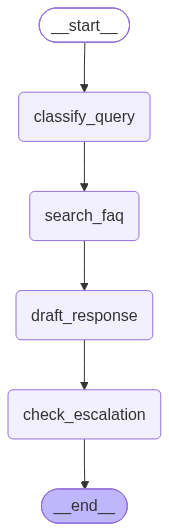

In [32]:
# Візуалізація графа
from IPython.display import Image, display

try:
    display(Image(agent_preview.get_graph().draw_mermaid_png()))
except Exception as error:
    print("Не вдалося намалювати схему, показуємо текстом:", type(error).__name__)
    print(agent_preview.get_graph().draw_ascii())

In [33]:
# Пробний наскрізний прогон однієї гілки перед повним експериментом
probe_stats = []
probe_agent = build_support_agent(mode="hybrid", llm=make_llm(MODELS["luna"]), stats=probe_stats)

probe_result = probe_agent.invoke(
    {"user_query": TEST_QUERIES[1], "needs_escalation": False},
    {"configurable": {"thread_id": "probe"}},
)

print("ЗАПИТ:", TEST_QUERIES[1])
print()
print("КЛАСИФІКАЦІЯ:", probe_result["classification"])
print()
print("ЗНАЙДЕНО В БАЗІ:", probe_result["search_results"])
print()
print("ВІДПОВІДЬ:")
print(probe_result["draft_response"])
print()
print("ЕСКАЛАЦІЯ:", probe_result["needs_escalation"])
print("СЛІВ У ВІДПОВІДІ:", count_words(probe_result["draft_response"]))
print()
print("Викликів моделі:", len(probe_stats))
print("Токенів:", sum(item["tokens"] for item in probe_stats))
print("Вартість:", f"{sum(item['cost'] for item in probe_stats):.6f}")

ЗАПИТ: З мене двічі зняли гроші за підписку! Це шахрайство! Поверніть кошти негайно!

КЛАСИФІКАЦІЯ: {'type': 'complaint', 'category': 'payment', 'urgency': 'high', 'summary': 'Користувач повідомляє про подвійне списання за підписку та вимагає негайного повернення коштів.'}

ЗНАЙДЕНО В БАЗІ: ['Подвійне списання повернеться автоматично за 3-5 днів']

ВІДПОВІДЬ:
Подвійно списана сума повернеться автоматично протягом 3–5 днів. Додаткових дій не потрібно. Якщо кошти не повернуться після цього терміну, зверніться повторно та надайте дату й суму списання.

⚠️ Запит передано спеціалісту (відповідь за 24 год).

ЕСКАЛАЦІЯ: True
СЛІВ У ВІДПОВІДІ: 35

Викликів моделі: 2
Токенів: 836
Вартість: 0.000292


## 7. Метрики якості

Три метрики задані умовою: Task Completion Rate, Answer Relevancy і
Escalation Rate. Для порівняння архітектур їх замало: показник Escalation
Rate у 40 відсотків можна отримати і на помилковій парі звернень, бо він
рахує лише кількість, а не влучність. Тому додано ще чотири вимірювання
відносно еталона з умови: точність категорій, точність ескалації, точність
типів і частка відповідей у межах 50 слів.

Релевантність оцінює окрема модель-суддя `claude-haiku-4.5`, яка не бере
участі в порівнянні. Якби суддею була одна з чотирьох моделей-учасниць,
вона оцінювала б власні відповіді, і порівняння втратило б сенс.

Довжина відповіді рахується без службової приписки про передачу
спеціалісту, бо це текст агента, а не модельна відповідь.

In [35]:
judge_llm = make_llm(JUDGE_MODEL)


def calculate_answer_relevancy(query: str, response: str) -> float:
    """Оцінка релевантності відповіді окремою моделлю-суддею"""

    relevancy_prompt = f"""
    Оцінка релевантності (0-1):
    Запит: {query}
    Відповідь: {response}

    Тільки число:
    """

    try:
        result = judge_llm.invoke(relevancy_prompt)
        found = re.search(r"\d+(?:[.,]\d+)?", result.content.strip())
        if not found:
            return 0.5
        score = float(found.group().replace(",", "."))
        return min(max(score, 0.0), 1.0)
    except Exception:
        return 0.5


# Перевірка судді на свідомо доречній і свідомо недоречній відповіді
print("Доречна відповідь:",
      calculate_answer_relevancy(TEST_QUERIES[0],
                                 "Натисніть 'Забули пароль?' та перевірте пошту."))
print("Недоречна відповідь:",
      calculate_answer_relevancy(TEST_QUERIES[0],
                                 "Підтримка працює цілодобово, гарного дня."))

Доречна відповідь: 0.9
Недоречна відповідь: 0.1


## 8. Експеримент 1: гібридна архітектура на чотирьох моделях

Кожна комбінація проганяється на тих самих п'яти зверненнях з умови.
Для безкоштовних моделей між зверненнями робиться пауза, щоб не впертись
в обмеження двадцять запитів на хвилину. Помилковий виклик повторюється
один раз, після чого звернення позначається як невиконане, а прогін
триває далі: зупиняти весь експеримент через одну відмову безкоштовного
провайдера сенсу немає.

In [41]:
# Накопичувачі результатів експерименту.
# Ініціалізуються лише один раз за сесію: у зошиті комірки часто
# перезапускають, і звичайне присвоєння стирало б уже зібрані прогони.
try:
    RESULTS, DETAILS
except NameError:
    RESULTS, DETAILS = {}, {}

print("Комбінацій у таблиці:", len(RESULTS))

In [42]:
import time


def run_combination(label: str, mode: str, model_key: str) -> dict:
    """Проганяє одну комбінацію моделі та архітектури на п'яти зверненнях."""
    slug = MODELS[model_key]
    # Повністю LLM-архітектура робить удвічі більше викликів на одне
    # звернення, тому для безкоштовних моделей пауза більша.
    pause = (5.0 if mode == "full_llm" else 3.0) if ":free" in slug else 0.0
    stats = []
    agent = build_support_agent(mode=mode, llm=make_llm(slug), stats=stats)

    rows = []
    started = time.time()

    for index, query in enumerate(TEST_QUERIES):
        state, error_text = None, None
        for attempt in (1, 2):
            try:
                state = agent.invoke(
                    {"user_query": query, "needs_escalation": False},
                    {"configurable": {"thread_id": f"{label}_{index}_{attempt}"}},
                )
                error_text = None
                break
            except Exception as error:
                error_text = f"{type(error).__name__}: {str(error)[:140]}"
                if attempt == 1:
                    time.sleep(20)

        classification = (state or {}).get("classification") or {}
        full_answer = (state or {}).get("draft_response") or ""
        clean_answer = full_answer.replace(ESCALATION_NOTICE, "").strip()

        rows.append({
            "index": index,
            "query": query,
            "type": classification.get("type"),
            "category": classification.get("category"),
            "urgency": classification.get("urgency"),
            "summary": classification.get("summary"),
            "faq": (state or {}).get("search_results") or [],
            "answer": clean_answer,
            "escalation": bool((state or {}).get("needs_escalation")),
            "words": count_words(clean_answer),
            "error": error_text,
        })

        print(f"   {index + 1}/5 {'помилка' if error_text else 'готово'}")
        if pause:
            time.sleep(pause)

    duration = time.time() - started
    completed = [row for row in rows if row["error"] is None and row["answer"]]
    relevancy = [calculate_answer_relevancy(row["query"], row["answer"]) for row in completed]

    summary = {
        "label": label,
        "mode": mode,
        "model": model_key,
        "tcr": len(completed) / len(TEST_QUERIES),
        "relevancy": sum(relevancy) / len(relevancy) if relevancy else 0.0,
        "escalation_rate": sum(row["escalation"] for row in rows) / len(rows),
        "category_acc": sum(1 for row, ref in zip(rows, EXPECTED) if row["category"] == ref["category"]) / len(EXPECTED),
        "escalation_acc": sum(1 for row, ref in zip(rows, EXPECTED) if row["escalation"] == ref["escalation"]) / len(EXPECTED),
        "type_acc": sum(1 for row, ref in zip(rows, EXPECTED) if row["type"] == ref["type"]) / len(EXPECTED),
        "within_50": sum(1 for row in completed if row["words"] <= 50) / len(completed) if completed else 0.0,
        "seconds": duration,
        "calls": len(stats),
        "tokens": sum(item["tokens"] for item in stats),
        "cost": sum(item["cost"] for item in stats),
        "errors": sum(1 for row in rows if row["error"]),
    }

    RESULTS[label] = summary
    DETAILS[label] = rows
    return summary


print("Рушій експерименту готовий. Комбінацій у таблиці вже:", len(RESULTS))

Рушій експерименту готовий. Комбінацій у таблиці вже: 0


In [45]:
print("Гібридна архітектура на чотирьох моделях\n")

for model_key in MODELS:
    label = f"hybrid_{model_key}"
    if label in RESULTS:
        print(f"{label}: вже пораховано, пропускаємо\n")
        continue
    print(f"{label} ({MODELS[model_key]}):")
    summary = run_combination(label, "hybrid", model_key)
    print(f"   категорії {summary['category_acc']:.0%}"
          f" | ескалація {summary['escalation_acc']:.0%}"
          f" | типи {summary['type_acc']:.0%}"
          f" | релевантність {summary['relevancy']:.0%}"
          f" | до 50 слів {summary['within_50']:.0%}"
          f" | {summary['seconds']:.0f} с"
          f" | ${summary['cost']:.5f}"
          f" | помилок {summary['errors']}\n")

print("Готово. Комбінацій у таблиці:", len(RESULTS), sorted(RESULTS))

Гібридна архітектура на чотирьох моделях

hybrid_luna: вже пораховано, пропускаємо

hybrid_gpt5_mini: вже пораховано, пропускаємо

hybrid_nemotron: вже пораховано, пропускаємо

hybrid_dots (dots-studio/dots-3-note-preview:free):
   1/5 готово
   2/5 готово
   3/5 готово
   4/5 готово
   5/5 готово
   категорії 100% | ескалація 100% | типи 80% | релевантність 76% | до 50 слів 100% | 73 с | $0.00000 | помилок 0

Готово. Комбінацій у таблиці: 4 ['hybrid_dots', 'hybrid_gpt5_mini', 'hybrid_luna', 'hybrid_nemotron']


## 9. Експеримент 2: повністю LLM-архітектура

Ті самі чотири моделі проганяються на другій архітектурі, щоб порівняння
було повним: чотири моделі на дві архітектури дають вісім комбінацій.

У цій архітектурі модель додатково обирає пункти бази знань і сама ухвалює
рішення про ескалацію, причому правило ескалації передане їй у промпті
дослівно. Кількість викликів моделі на одне звернення зростає з двох до
чотирьох, тому цей експеримент помітно повільніший і дорожчий за перший.

In [46]:
print("Повністю LLM-архітектура на чотирьох моделях\n")

for model_key in MODELS:
    label = f"full_llm_{model_key}"
    if label in RESULTS:
        print(f"{label}: вже пораховано, пропускаємо\n")
        continue
    print(f"{label} ({MODELS[model_key]}):")
    summary = run_combination(label, "full_llm", model_key)
    print(f"   категорії {summary['category_acc']:.0%}"
          f" | ескалація {summary['escalation_acc']:.0%}"
          f" | типи {summary['type_acc']:.0%}"
          f" | релевантність {summary['relevancy']:.0%}"
          f" | до 50 слів {summary['within_50']:.0%}"
          f" | {summary['seconds']:.0f} с"
          f" | ${summary['cost']:.5f}"
          f" | помилок {summary['errors']}\n")

print("Готово. Комбінацій у таблиці:", len(RESULTS), sorted(RESULTS))

Повністю LLM-архітектура на чотирьох моделях

full_llm_luna (openai/gpt-5.6-luna):
   1/5 готово
   2/5 готово
   3/5 готово
   4/5 готово
   5/5 готово
   категорії 100% | ескалація 100% | типи 80% | релевантність 85% | до 50 слів 100% | 31 с | $0.00263 | помилок 0

full_llm_gpt5_mini (openai/gpt-5-mini):
   1/5 готово
   2/5 готово
   3/5 готово
   4/5 готово
   5/5 готово
   категорії 100% | ескалація 100% | типи 100% | релевантність 80% | до 50 слів 100% | 147 с | $0.02086 | помилок 0

full_llm_nemotron (nvidia/nemotron-3-super-120b-a12b:free):
   1/5 помилка
   2/5 помилка
   3/5 готово
   4/5 готово
   5/5 помилка
   категорії 40% | ескалація 80% | типи 20% | релевантність 68% | до 50 слів 100% | 366 с | $0.00000 | помилок 3

full_llm_dots (dots-studio/dots-3-note-preview:free):
   1/5 готово
   2/5 готово
   3/5 готово
   4/5 готово
   5/5 готово
   категорії 100% | ескалація 100% | типи 60% | релевантність 76% | до 50 слів 100% | 125 с | $0.00000 | помилок 0

Готово. Комбінацій

## 10. Порівняльна таблиця та вибір переможця

Вісім комбінацій: чотири моделі на дві архітектури. Сортування за
точністю категорій, потім ескалації, потім типів, і вже потім за
вартістю, бо саме такий порядок відповідає вазі критеріїв завдання.

Переможець обирається кодом за таблицею, а не вручну: далі саме він
підставляється у `build_support_agent()` за замовчуванням.

In [47]:
import pandas as pd

table = pd.DataFrame([
    {
        "комбінація": row["label"],
        "архітектура": "гібрид" if row["mode"] == "hybrid" else "повний LLM",
        "модель": row["model"],
        "TCR": row["tcr"],
        "категорії": row["category_acc"],
        "ескалація": row["escalation_acc"],
        "типи": row["type_acc"],
        "релевантність": row["relevancy"],
        "ескалацій": row["escalation_rate"],
        "до 50 слів": row["within_50"],
        "помилок": row["errors"],
        "секунд": round(row["seconds"]),
        "вартість": row["cost"],
    }
    for row in RESULTS.values()
])

table = table.sort_values(
    by=["категорії", "ескалація", "типи", "вартість"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

percent = ["TCR", "категорії", "ескалація", "типи", "релевантність", "ескалацій", "до 50 слів"]
display(table.style.format({**{column: "{:.0%}" for column in percent}, "вартість": "${:.5f}"}))

,комбінація,архітектура,модель,TCR,категорії,ескалація,типи,релевантність,ескалацій,до 50 слів,помилок,секунд,вартість
0,hybrid_gpt5_mini,гібрид,gpt5_mini,100%,100%,100%,100%,70%,40%,100%,0,106,$0.01502
1,full_llm_gpt5_mini,повний LLM,gpt5_mini,100%,100%,100%,100%,80%,40%,100%,0,147,$0.02086
2,hybrid_nemotron,гібрид,nemotron,100%,100%,100%,80%,77%,40%,100%,0,1105,$0.00000
3,hybrid_dots,гібрид,dots,100%,100%,100%,80%,76%,40%,100%,0,73,$0.00000
4,hybrid_luna,гібрид,luna,100%,100%,100%,80%,82%,40%,100%,0,19,$0.00163
5,full_llm_luna,повний LLM,luna,100%,100%,100%,80%,85%,40%,100%,0,31,$0.00263
6,full_llm_dots,повний LLM,dots,100%,100%,100%,60%,76%,40%,100%,0,125,$0.00000
7,full_llm_nemotron,повний LLM,nemotron,40%,40%,80%,20%,68%,20%,100%,3,366,$0.00000


In [48]:
# Переможець: найкраща точність, за рівності точностей дешевша комбінація
best = min(
    RESULTS.values(),
    key=lambda row: (
        -row["category_acc"],
        -row["escalation_acc"],
        -row["type_acc"],
        row["cost"],
    ),
)

DEFAULT_MODE = best["mode"]
DEFAULT_MODEL = MODELS[best["model"]]

print("ПЕРЕМОЖЕЦЬ")
print(f"  архітектура: {'гібридна' if best['mode'] == 'hybrid' else 'повністю LLM'}")
print(f"  модель: {best['model']} ({DEFAULT_MODEL})")
print(f"  категорії {best['category_acc']:.0%}, ескалація {best['escalation_acc']:.0%}, типи {best['type_acc']:.0%}")
print(f"  релевантність {best['relevancy']:.0%}, вартість прогону ${best['cost']:.5f}, час {best['seconds']:.0f} с")
print()
print("Саме ця комбінація стоїть за замовчуванням у build_support_agent().")

ПЕРЕМОЖЕЦЬ
  архітектура: гібридна
  модель: gpt5_mini (openai/gpt-5-mini)
  категорії 100%, ескалація 100%, типи 100%
  релевантність 70%, вартість прогону $0.01502, час 106 с

Саме ця комбінація стоїть за замовчуванням у build_support_agent().


In [49]:
print("Розбіжності з еталоном\n")

for label in sorted(DETAILS):
    problems = []
    for row, reference in zip(DETAILS[label], EXPECTED):
        number = row["index"] + 1
        if row["error"]:
            problems.append(f"звернення {number}: відмова провайдера")
            continue
        if row["category"] != reference["category"]:
            problems.append(f"звернення {number}: категорія {row['category']} замість {reference['category']}")
        if row["type"] != reference["type"]:
            problems.append(f"звернення {number}: тип {row['type']} замість {reference['type']}")
        if row["escalation"] != reference["escalation"]:
            problems.append(f"звернення {number}: ескалація {row['escalation']} замість {reference['escalation']}")

    print(f"{label}: {'усе за еталоном' if not problems else str(len(problems)) + ' розбіжностей'}")
    for line in problems:
        print(f"   {line}")
    print()

Розбіжності з еталоном

full_llm_dots: 2 розбіжностей
   звернення 1: тип question замість problem
   звернення 4: тип problem замість complaint

full_llm_gpt5_mini: усе за еталоном

full_llm_luna: 1 розбіжностей
   звернення 1: тип question замість problem

full_llm_nemotron: 4 розбіжностей
   звернення 1: відмова провайдера
   звернення 2: відмова провайдера
   звернення 4: тип problem замість complaint
   звернення 5: відмова провайдера

hybrid_dots: 1 розбіжностей
   звернення 1: тип question замість problem

hybrid_gpt5_mini: усе за еталоном

hybrid_luna: 1 розбіжностей
   звернення 1: тип question замість problem

hybrid_nemotron: 1 розбіжностей
   звернення 1: тип question замість problem



In [50]:
import json

# Компактна вигрузка для незалежної перевірки якості відповідей
dump = {
    label: [
        {
            "n": row["index"] + 1,
            "cat": row["category"],
            "type": row["type"],
            "urg": row["urgency"],
            "esc": row["escalation"],
            "w": row["words"],
            "faq": row["faq"],
            "answer": row["answer"],
        }
        for row in DETAILS[label]
    ]
    for label in sorted(DETAILS)
}

print(json.dumps(dump, ensure_ascii=False, indent=1))

{
 "full_llm_dots": [
  {
   "n": 1,
   "cat": "password",
   "type": "question",
   "urg": "medium",
   "esc": false,
   "w": 27,
   "faq": [
    "Скидання пароля: Натисніть 'Забули пароль?' → введіть email → перевірте пошту",
    "Новий пароль: мінімум 8 символів з літерами та цифрами"
   ],
   "answer": "Натисніть \"Забули пароль?\" на сторінці входу. Введіть ваш email. Перевірте пошту і перейдіть за посиланням. Створіть новий пароль: мінімум 8 символів, обов'язково літери та цифри. Підтвердіть зміни."
  },
  {
   "n": 2,
   "cat": "payment",
   "type": "complaint",
   "urg": "high",
   "esc": true,
   "w": 21,
   "faq": [
    "Перевірте дані картки та баланс",
    "Подвійне списання повернеться автоматично за 3-5 днів"
   ],
   "answer": "Перевірте баланс картки. Подвійне списання повернеться автоматично протягом 3-5 днів. Якщо кошти не надійдуть, зверніться до служби підтримки для ручного розслідування."
  },
  {
   "n": 3,
   "cat": "payment",
   "type": "question",
   "urg": "lo

### Висновки

**Задача розв'язується стабільно, різниця між моделями не в тому, чи вони
справляються.** Сім комбінацій з восьми виконали всі вимоги умови: п'ять
відповідей з п'яти, сто відсотків точності за категоріями і ескалацією,
Escalation Rate рівно сорок відсотків, усі відповіді в межах 50 слів.
Провалилась одна комбінація, `nemotron` на повністю LLM-архітектурі:
три відмови провайдера з п'яти звернень, точність категорій сорок відсотків.

**Передавати моделі те, що вже задано формулою, невигідно.** Гібридна і
повністю LLM-архітектура дали однакову точність на обох платних моделях,
але друга коштувала дорожче і працювала довше: у `gpt5_mini` 0.021 проти
0.015 долара і 147 секунд проти 106. Моє початкове припущення було інше.
Я очікував, що модель почне порушувати правило ескалації, коли його
передано текстом у промпті замість коду, але точність ескалації трималась
на ста відсотках у семи комбінаціях з восьми. Виграш гібрида не в
надійності правила, а в ціні й швидкості за той самий результат.

**Зате пошук у базі знань модель справді псує, і це видно на текстах.**
На п'ятому зверненні про корпоративний акаунт `dots` у повністю
LLM-архітектурі обрала з бази пункт «Перевірте правильність email» замість
пункту «Корпоративні акаунти: розділ Управління командою», і відповідь
поїхала у вигаданий «розділ Користувачі», якого в базі немає. Та сама
модель на гібриді, де пункт обирав код, узяла правильний пункт і дала
правильну відповідь. Там же на четвертому зверненні повністю LLM-архітектура
притягнула в контекст очищення кешу для сайту, який лежить третю годину.

**Слабка модель на архітектурі з більшою свободою ломається непропорційно.**
`nemotron` на гібриді дала сто відсотків за категоріями і вісімдесят за
типами. Та сама модель на повністю LLM-архітектурі, де до двох викликів
додалися ще два, дала сорок і двадцять відсотків та три відмови. Кількість
рішень, віддана моделі, працює як множник її слабкості, а не як спосіб
отримати від неї більше.

**Безкоштовні моделі працюють, але покладатись на них не можна.** Обидві
безкоштовні моделі впоралися з категоріями і ескалацією на сто відсотків у
гібриді, тобто для цієї задачі їх достатньо. Проблема не в якості, а в
передбачуваності. Та сама комбінація `nemotron` на гібриді під час різних
запусків виконувалась від 95 до 1105 секунд. `dots` при `temperature=0`
давала то шістдесят, то вісімдесят відсотків точності за типами.
Початково четвертим учасником планувалась `gemma-4-31b-it:free`, але її
ендпоінт відповідав помилкою 429 на кожну спробу, тому її довелось замінити
ще до початку експерименту.

**Найгірший дефект у наборі це вигаданий контакт.** `nemotron` дописала у
відповідь адресу `support@example.com`, якої немає ні в базі знань, ні в
промпті. Неточне формулювання користувач переживе, а вигаданою адресою він
скористається.

**Переможець за метриками і переможець за якістю тексту це різні
комбінації.** Формально виграв гібрид на `gpt5_mini`: єдина модель, яка
попала в еталон за всіма трьома вимірами, включно з типами. Але тексти
`luna` читаються краще. На третьому зверненні «чи можу я змінити тарифний
план» `luna` спершу відповідає на поставлене питання («Так, змінити можна»),
а вже потім дає кроки, тоді як `gpt5_mini` видає дев'ять слів чистої
команди без відповіді. На четвертому зверненні про збій `luna` пише про
орієнтовний час відновлення, тобто відповідає саме на питання «коли», а
`gpt5_mini` радить оновлювати сторінку кожні п'ять хвилин і надіслати
скріншот, що людині з тригодинним простоєм не допомагає. До того ж
`gpt5_mini` у двох відповідях з п'яти переходить на розмітку списками,
тобто не тримає єдиний формат у межах одного прогону.

**Ціна цього вибору.** `luna` при тій самій точності за категоріями і
ескалацією дешевша у дев'ять разів (0.0016 проти 0.015 долара) і швидша у
п'ять (19 секунд проти 106). Різниця між ними лише в типах звернення,
вісімдесят відсотків проти ста, а тип у цьому агенті не впливає ні на
пошук, ні на відповідь, ні на ескалацію. Для навчальної роботи обрано
`gpt5_mini` як максимально точний варіант, але для реального сервісу з
таким навантаженням я взяв би `luna`.

**Усі помилки за типами зібрані в одному зверненні.** Шість комбінацій з
восьми назвали «Я забув пароль від свого акаунту, як його відновити?»
питанням замість проблеми. Це не слабкість моделей, а межа визначення: за
формою це питання, за суттю це проблема. Стійко розрізнила лише
`gpt5_mini`.

**Метрика релевантності виявилась м'якою.** У `gpt5_mini` вона дала
сімдесят відсотків на гібриді і вісімдесят на повністю LLM-архітектурі,
хоча самі відповіді там майже однакові. Розкид близько десяти пунктів на
однаковому матеріалі означає, що обирати переможця за цією метрикою не
можна, і добре, що вибір робився за точністю.

**Обмеження цієї роботи.** Один прогін на комбінацію, п'ять звернень,
одна модель-суддя. Для навчального порівняння цього достатньо, для
рішення про промислове використання замало: потрібні щонайменше кілька
прогонів на комбінацію і ширший набір звернень, включно з такими, яких
немає в базі знань.

## 11. Фінальне рішення

`build_support_agent()` без аргументів повертає комбінацію, яку обрала
порівняльна таблиця вище: гібридна архітектура на моделі, що показала
найвищу точність. Нижче наведено тестову функцію з умови завдання без
змін і її запуск на п'яти обов'язкових зверненнях.

In [51]:
def test_agent():
    """Тестування агента на 5 запитах"""

    agent = build_support_agent()

    test_queries = [
        "Я забув пароль від свого акаунту, як його відновити?",
        "З мене двічі зняли гроші за підписку! Це шахрайство! Поверніть кошти негайно!",
        "Чи можу я змінити тарифний план на дешевший?",
        "Сайт не працює вже третю годину! Коли полагодите?",
        "Як додати нового користувача до корпоративного акаунту?"
    ]

    results = []
    relevancy_scores = []

    print("=" * 70)
    print("ТЕСТУВАННЯ АГЕНТА ТЕХНІЧНОЇ ПІДТРИМКИ")
    print("=" * 70)

    for i, query in enumerate(test_queries, 1):
        print(f"\n{'='*70}")
        print(f"📧 ТЕСТ {i}/5")
        print(f"{'='*70}")
        print(f"ЗАПИТ: {query}")
        print("-" * 70)

        initial_state = {
            "user_query": query,
            "needs_escalation": False
        }

        config = {"configurable": {"thread_id": f"test_{i}"}}

        try:
            result = agent.invoke(initial_state, config)
            results.append(result)

            if result.get("classification"):
                cls = result["classification"]
                print(f"\n📊 КЛАСИФІКАЦІЯ:")
                print(f"   Тип: {cls.get('type')}")
                print(f"   Категорія: {cls.get('category')}")
                print(f"   Терміновість: {cls.get('urgency')}")
                print(f"   Резюме: {cls.get('summary')}")

            if result.get("search_results"):
                print(f"\n🔍 FAQ ({len(result['search_results'])} пунктів):")
                for j, faq in enumerate(result['search_results'], 1):
                    print(f"   {j}. {faq}")

            if result.get("draft_response"):
                print(f"\n💬 ВІДПОВІДЬ АГЕНТА:")
                print("-" * 70)
                print(result["draft_response"])
                print("-" * 70)

                relevancy = calculate_answer_relevancy(query, result["draft_response"])
                relevancy_scores.append(relevancy)
                print(f"\n📈 Релевантність: {relevancy:.0%}")

            if result.get("needs_escalation"):
                print("\n⚠️ СТАТУС: Ескаловано до спеціаліста")
            else:
                print("\n✅ СТАТУС: Оброблено автоматично")

        except Exception as e:
            print(f"❌ ПОМИЛКА: {e}")
            results.append({})

    print(f"\n{'='*70}")
    print("ПІДСУМКОВІ МЕТРИКИ")
    print("=" * 70)

    completed = sum(1 for r in results if r.get("draft_response"))
    tcr = completed / len(results) if results else 0
    print(f"✅ Task Completion Rate: {tcr:.0%} ({completed}/{len(results)})")

    if relevancy_scores:
        avg_relevancy = sum(relevancy_scores) / len(relevancy_scores)
        print(f"🎯 Average Answer Relevancy: {avg_relevancy:.0%}")

    escalated = sum(1 for r in results if r.get("needs_escalation"))
    print(f"📊 Escalation Rate: {escalated}/{len(results)} ({escalated/len(results)*100:.0f}%)")

    print("=" * 70)

    return results

In [52]:
final_results = test_agent()

ТЕСТУВАННЯ АГЕНТА ТЕХНІЧНОЇ ПІДТРИМКИ

📧 ТЕСТ 1/5
ЗАПИТ: Я забув пароль від свого акаунту, як його відновити?
----------------------------------------------------------------------

📊 КЛАСИФІКАЦІЯ:
   Тип: problem
   Категорія: password
   Терміновість: medium
   Резюме: Користувач забув пароль до свого акаунту і просить інструкцію зі скидання/відновлення пароля.

🔍 FAQ (1 пунктів):
   1. Скидання пароля: Натисніть 'Забули пароль?' → введіть email → перевірте пошту

💬 ВІДПОВІДЬ АГЕНТА:
----------------------------------------------------------------------
- Натисніть кнопку Забули пароль
- Введіть email свого акаунту
- Перевірте електронну пошту та відкрийте лист для відновлення пароля
----------------------------------------------------------------------

📈 Релевантність: 95%

✅ СТАТУС: Оброблено автоматично

📧 ТЕСТ 2/5
ЗАПИТ: З мене двічі зняли гроші за підписку! Це шахрайство! Поверніть кошти негайно!
----------------------------------------------------------------------

📊 КЛАСИФІК